<a href="https://colab.research.google.com/github/Pubudu-98/Colab/blob/main/Atlas_lab_data_labeled_samples_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Analysis

In [15]:
import pandas as pd

with open('/content/Verifications - Atlas@22.txt', 'r') as f:
    data = f.readlines()

data = [item.strip() for item in data]
df = pd.DataFrame(data, columns=['Status'])

display(df.head())

,Status
0,Prod V2 Verifications:
1,1. Rolling - Rejected
2,2. Rolling - Rejected
3,3. Rolling - Rejected
4,4. Standing up - Accepted


In [16]:
display(df.head())

,Status
0,Prod V2 Verifications:
1,1. Rolling - Rejected
2,2. Rolling - Rejected
3,3. Rolling - Rejected
4,4. Standing up - Accepted


In [17]:
display(df.head())

,Status
0,Prod V2 Verifications:
1,1. Rolling - Rejected
2,2. Rolling - Rejected
3,3. Rolling - Rejected
4,4. Standing up - Accepted


In [18]:
df['Category'] = df['Status'].apply(lambda x: 'Accepted' if 'Accepted' in x else ('Rejected' if 'Rejected' in x else 'Other'))
display(df.head())

,Status,Category
0,Prod V2 Verifications:,Other
1,1. Rolling - Rejected,Rejected
2,2. Rolling - Rejected,Rejected
3,3. Rolling - Rejected,Rejected
4,4. Standing up - Accepted,Accepted


In [19]:
category_counts = df['Category'].value_counts()
display(category_counts)

,count
Category,
Accepted,28
Rejected,20
Other,3


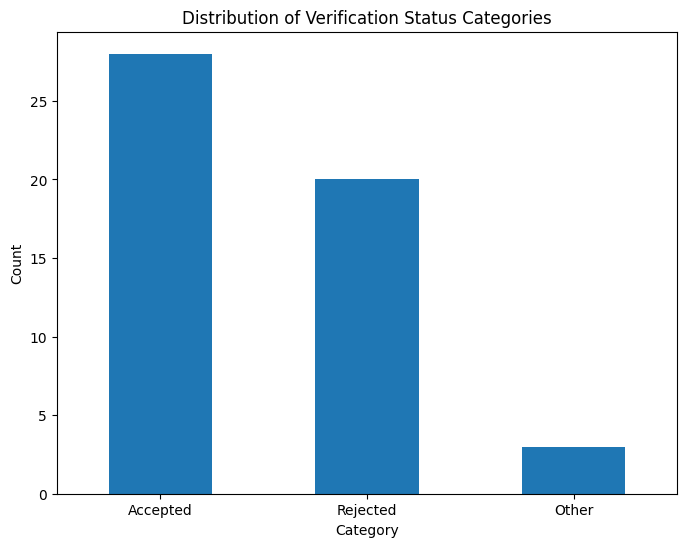

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Distribution of Verification Status Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [21]:
import plotly.express as px

# Create a new DataFrame with counts for each unique status
status_counts = df['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

# Add the 'Category' column to the status_counts DataFrame for coloring/grouping
status_counts['Category'] = status_counts['Status'].apply(lambda x: 'Accepted' if 'Accepted' in x else ('Rejected' if 'Rejected' in x else 'Other'))

# Create the treemap
fig = px.treemap(status_counts,
                 path=[px.Constant("all"), 'Category', 'Status'],
                 values='Count',
                 color='Category',
                 hover_data=['Status', 'Count'],
                 title='Detailed Distribution of Verification Statuses')

fig.show()